# Valorisation d'options par le modèle de Cox-Ross-Rubinstein

Projet 4A MAM — Estimation de la valeur d'option pour le modèle CRR

**Sous-jacents étudiés :** CAC 40 (indice boursier, ticker `^FCHI`) et Brent (matière première, ticker `BZ=F`)

**Objectif :** calibrer le modèle CRR sur des données réelles, comparer ses prix théoriques à ceux de Black-Scholes, et analyser la convergence du modèle en fonction du nombre d'étapes N.

**Convention importante :**
- Les données `yfinance` fournissent le prix réel *du sous-jacent* (CAC 40 ou Brent). Elles servent à calibrer la volatilité et à simuler une trajectoire de l'actif.
- Le prix *de l'option* calculé par CRR est comparé au prix théorique de Black-Scholes, utilisé comme référence analytique. Aucun prix réel d'option cotée n'est disponible dans cette étude.

---

## 1. Importation des bibliothèques et des modules du projet

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import sys
from scipy.stats import norm

sys.path.append("../src")

from option import Option
from market_data import build_dataset, get_S0_and_log_returns
from calibration import calibrate_crr_parameters
from crr import crr_price
from backtester import compute_mae, compute_rmse, run_backtest, summarize_backtest_results, analyze_stability

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Modules chargés avec succès.")

Modules chargés avec succès.


## 2. Définition des actifs et des paramètres globaux

In [8]:
# Les deux actifs étudiés
ASSETS = {
    "CAC 40" : "^FCHI",
    "Brent"  : "BZ=F",
}

# Période historique
START_DATE = "2022-01-01"
END_DATE   = "2025-06-01"

# Paramètres de l'option
T           = 1.0     # maturité en années
N           = 100     # nombre d'étapes de l'arbre CRR
OPTION_TYPE = "call"  # option européenne call

# Taux sans risque annuel (taux court terme européen de référence)
R = 0.03   # 3 %

print(f"Actifs : {list(ASSETS.keys())}")
print(f"Période : {START_DATE} -> {END_DATE}")
print(f"T = {T} an | N = {N} étapes | Type = {OPTION_TYPE} | r = {R*100:.1f} %")

Actifs : ['CAC 40', 'Brent']
Période : 2022-01-01 -> 2025-06-01
T = 1.0 an | N = 100 étapes | Type = call | r = 3.0 %


## 3. Récupération des données et rendements logarithmiques

Les prix récupérés via `yfinance` sont les prix réels observés sur le marché pour chaque sous-jacent. Pour le CAC 40, il s'agit du niveau de l'indice ; pour le Brent, du prix du contrat à terme de référence.

In [9]:
datasets = {}

for name, ticker in ASSETS.items():
    df = build_dataset(ticker, START_DATE, END_DATE)
    datasets[name] = df
    S0, _ = get_S0_and_log_returns(df)
    print(f"{name} ({ticker}) : {len(df)} observations | dernier prix = {S0:.2f}")

CAC 40 (^FCHI) : 871 observations | dernier prix = 7751.89
Brent (BZ=F) : 856 observations | dernier prix = 63.90


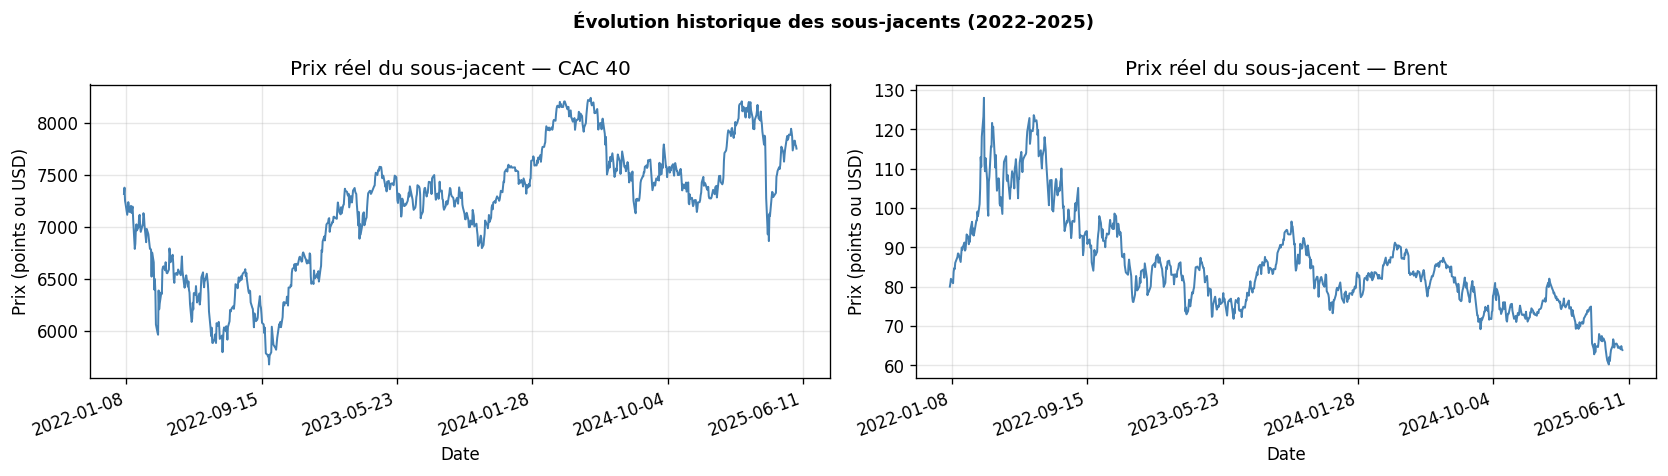

In [10]:
# --- Évolution des prix réels du sous-jacent ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    ax.plot(df.index, df["Close"], color="steelblue", linewidth=1.2)
    ax.set_title(f"Prix réel du sous-jacent — {name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Prix (points ou USD)")
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Évolution historique des sous-jacents (2022-2025)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("prix_sousjacents.png", bbox_inches="tight")
plt.show()

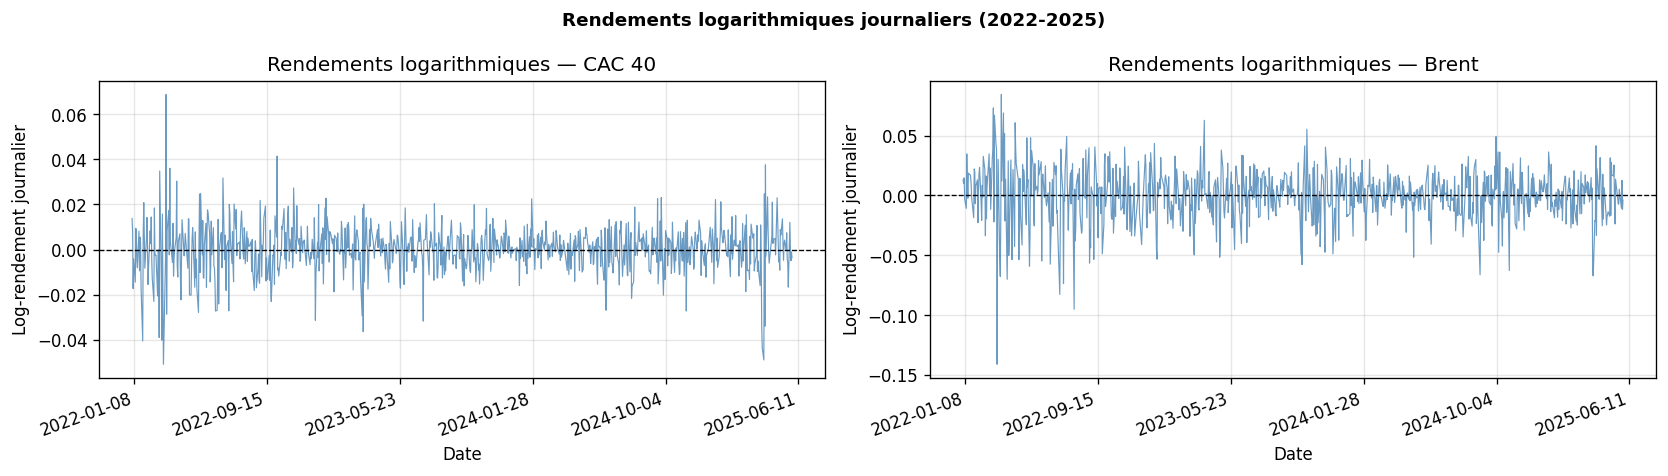

In [11]:
# --- Rendements logarithmiques ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    ax.plot(df.index, df["log_return"], color="steelblue", linewidth=0.7, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Rendements logarithmiques — {name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Log-rendement journalier")
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Rendements logarithmiques journaliers (2022-2025)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("rendements_log.png", bbox_inches="tight")
plt.show()

In [12]:
# --- Statistiques descriptives des rendements ---
print(f"{'Statistique':<28} {'CAC 40':>12} {'Brent':>12}")
print("-" * 55)

stats = {}
for name, df in datasets.items():
    lr = df["log_return"].dropna()
    mu  = lr.mean() * 252
    sig = lr.std(ddof=1) * np.sqrt(252)
    stats[name] = {"mu_annuel": mu, "sigma_annuel": sig, "n": len(lr)}
    print(f"Nb observations          : {len(lr):>12d}")

for label, key in [("Rendement annuel moyen", "mu_annuel"),
                   ("Volatilité annualisée  ", "sigma_annuel")]:
    row = f"{label:<28}"
    for name in ASSETS:
        row += f" {stats[name][key]*100:>11.2f}%"
    print(row)

Statistique                        CAC 40        Brent
-------------------------------------------------------
Nb observations          :          871
Nb observations          :          856
Rendement annuel moyen              2.07%       -6.24%
Volatilité annualisée              17.27%       35.18%


## 4. Calibration des paramètres

Pour chaque sous-jacent, le prix initial S0 correspond au dernier cours disponible. La volatilité sigma est estimée à partir des rendements logarithmiques historiques. Ces paramètres alimentent directement les modèles CRR et Black-Scholes.

In [13]:
calibrations = {}

for name, df in datasets.items():
    S0, log_returns = get_S0_and_log_returns(df)
    K = round(S0)  # option at-the-money
    params = calibrate_crr_parameters(log_returns, maturity=T, n_steps=N, risk_free_rate=R)
    calibrations[name] = {"S0": S0, "K": K, "log_returns": log_returns, **params}

# Tableau de synthèse des paramètres
rows = []
for name, c in calibrations.items():
    rows.append({
        "Actif"  : name,
        "S0"     : round(c["S0"], 2),
        "K (ATM)": round(c["K"], 2),
        "sigma"  : round(c["sigma"], 4),
        "r"      : c["r"],
        "T"      : T,
        "N"      : N,
        "u"      : round(c["u"], 6),
        "d"      : round(c["d"], 6),
        "p*"     : round(c["p_star"], 6),
    })

df_params = pd.DataFrame(rows)
print("Paramètres calibrés\n")
print(df_params.to_string(index=False))

Paramètres calibrés

 Actif      S0  K (ATM)  sigma    r   T   N        u        d       p*
CAC 40 7751.89     7752 0.1727 0.03 1.0 100 1.017425 0.982873 0.504365
 Brent   63.90       64 0.3518 0.03 1.0 100 1.035810 0.965428 0.495468


## 5. Modèle de Black-Scholes — référence théorique

La formule de Black-Scholes fournit un prix analytique exact pour une option européenne sous les hypothèses de log-normalité et de marché complet et sans friction. Dans cette étude, ce prix sert de référence pour évaluer la précision du modèle CRR.

In [14]:
def black_scholes_price(S0, K, T, r, sigma, option_type="call"):
    """Prix analytique de Black-Scholes pour une option européenne."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

# Vérification sur un cas standard
bs_test = black_scholes_price(100, 100, 1, 0.03, 0.20, "call")
print(f"Test Black-Scholes (S0=K=100, T=1, r=3%, sigma=20%) : {bs_test:.4f}")

for name, c in calibrations.items():
    bs = black_scholes_price(c["S0"], c["K"], T, R, c["sigma"], OPTION_TYPE)
    calibrations[name]["price_bs"] = bs
    print(f"{name:<8} -> Prix Black-Scholes = {bs:.4f}")

Test Black-Scholes (S0=K=100, T=1, r=3%, sigma=20%) : 9.4134
CAC 40   -> Prix Black-Scholes = 648.0697
Brent    -> Prix Black-Scholes = 9.7223


## 6. Modèle CRR — pricing et convergence

Le modèle binomial de Cox-Ross-Rubinstein discrétise l'espace des états du sous-jacent en un arbre à N étapes. À chaque noeud, le prix peut monter d'un facteur u ou baisser d'un facteur d, définis à partir de la volatilité historique. Le prix de l'option est calculé par rétropropagation sous la mesure risque-neutre.

In [15]:
# Pricing CRR pour chaque actif avec N = 100
results_pricing = []

for name, c in calibrations.items():
    option = Option(strike=c["K"], maturity=T, option_type=OPTION_TYPE)
    price_crr, _ = crr_price(
        S0=c["S0"], option=option,
        u=c["u"], d=c["d"], r=c["r"], dt=c["dt"], p_star=c["p_star"],
        american=False
    )
    price_bs = c["price_bs"]
    abs_err  = abs(price_crr - price_bs)
    rel_err  = abs_err / price_bs * 100 if price_bs != 0 else np.nan
    calibrations[name]["price_crr"] = price_crr

    results_pricing.append({
        "Actif"             : name,
        "S0"                : round(c["S0"], 2),
        "K"                 : round(c["K"], 2),
        "sigma"             : round(c["sigma"], 4),
        "Prix CRR"          : round(price_crr, 4),
        "Prix BS"           : round(price_bs, 4),
        "Erreur absolue"    : round(abs_err, 6),
        "Erreur relative %" : round(rel_err, 4),
    })

df_pricing = pd.DataFrame(results_pricing)
print("Tableau comparatif CRR vs Black-Scholes (N = 100)\n")
print(df_pricing.to_string(index=False))

Tableau comparatif CRR vs Black-Scholes (N = 100)

 Actif      S0    K  sigma  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
CAC 40 7751.89 7752 0.1727  646.7423 648.0697        1.327422             0.2048
 Brent   63.90   64 0.3518    9.7040   9.7223        0.018273             0.1880


### 6.1 Convergence du prix CRR en fonction de N

Lorsque N augmente, le pas de temps dt = T/N diminue, et la discrétisation de l'arbre binomial se rapproche du mouvement brownien géométrique continu supposé par Black-Scholes. Le prix CRR converge donc vers le prix analytique quand N tend vers l'infini.

In [16]:
N_values = [5, 10, 25, 50, 100, 200, 500, 1000]

conv_data = {name: [] for name in ASSETS}

for name, c in calibrations.items():
    S0, K = c["S0"], c["K"]
    price_bs = c["price_bs"]

    for n in N_values:
        p_n = calibrate_crr_parameters(c["log_returns"], maturity=T, n_steps=n, risk_free_rate=R)
        opt_n = Option(strike=K, maturity=T, option_type=OPTION_TYPE)
        price_n, _ = crr_price(
            S0=S0, option=opt_n,
            u=p_n["u"], d=p_n["d"], r=p_n["r"], dt=p_n["dt"], p_star=p_n["p_star"],
            american=False
        )
        abs_err = abs(price_n - price_bs)
        rel_err = abs_err / price_bs * 100
        conv_data[name].append({
            "N": n, "Prix CRR": round(price_n, 6),
            "Prix BS": round(price_bs, 6),
            "Erreur absolue": round(abs_err, 8),
            "Erreur relative %": round(rel_err, 6),
        })

# Affichage tableau de convergence pour chaque actif
for name in ASSETS:
    df_c = pd.DataFrame(conv_data[name])
    print(f"\n--- {name} (S0={calibrations[name]['S0']:.2f}, K={calibrations[name]['K']:.2f}) ---")
    print(df_c.to_string(index=False))


--- CAC 40 (S0=7751.89, K=7752.00) ---
   N   Prix CRR    Prix BS  Erreur absolue  Erreur relative %
   5 673.461173 648.069729       25.391444           3.918011
  10 634.936104 648.069729       13.133625           2.026576
  25 653.087690 648.069729        5.017961           0.774293
  50 645.415851 648.069729        2.653878           0.409505
 100 646.742307 648.069729        1.327422           0.204827
 200 647.406472 648.069729        0.663257           0.102344
 500 647.805021 648.069729        0.264708           0.040846
1000 647.937750 648.069729        0.131979           0.020365

--- Brent (S0=63.90, K=64.00) ---
   N  Prix CRR  Prix BS  Erreur absolue  Erreur relative %
   5 10.155647 9.722269        0.433378           4.457582
  10  9.516549 9.722269        0.205719           2.115961
  25  9.807765 9.722269        0.085497           0.879389
  50  9.683598 9.722269        0.038670           0.397748
 100  9.703995 9.722269        0.018273           0.187953
 200  9.71388

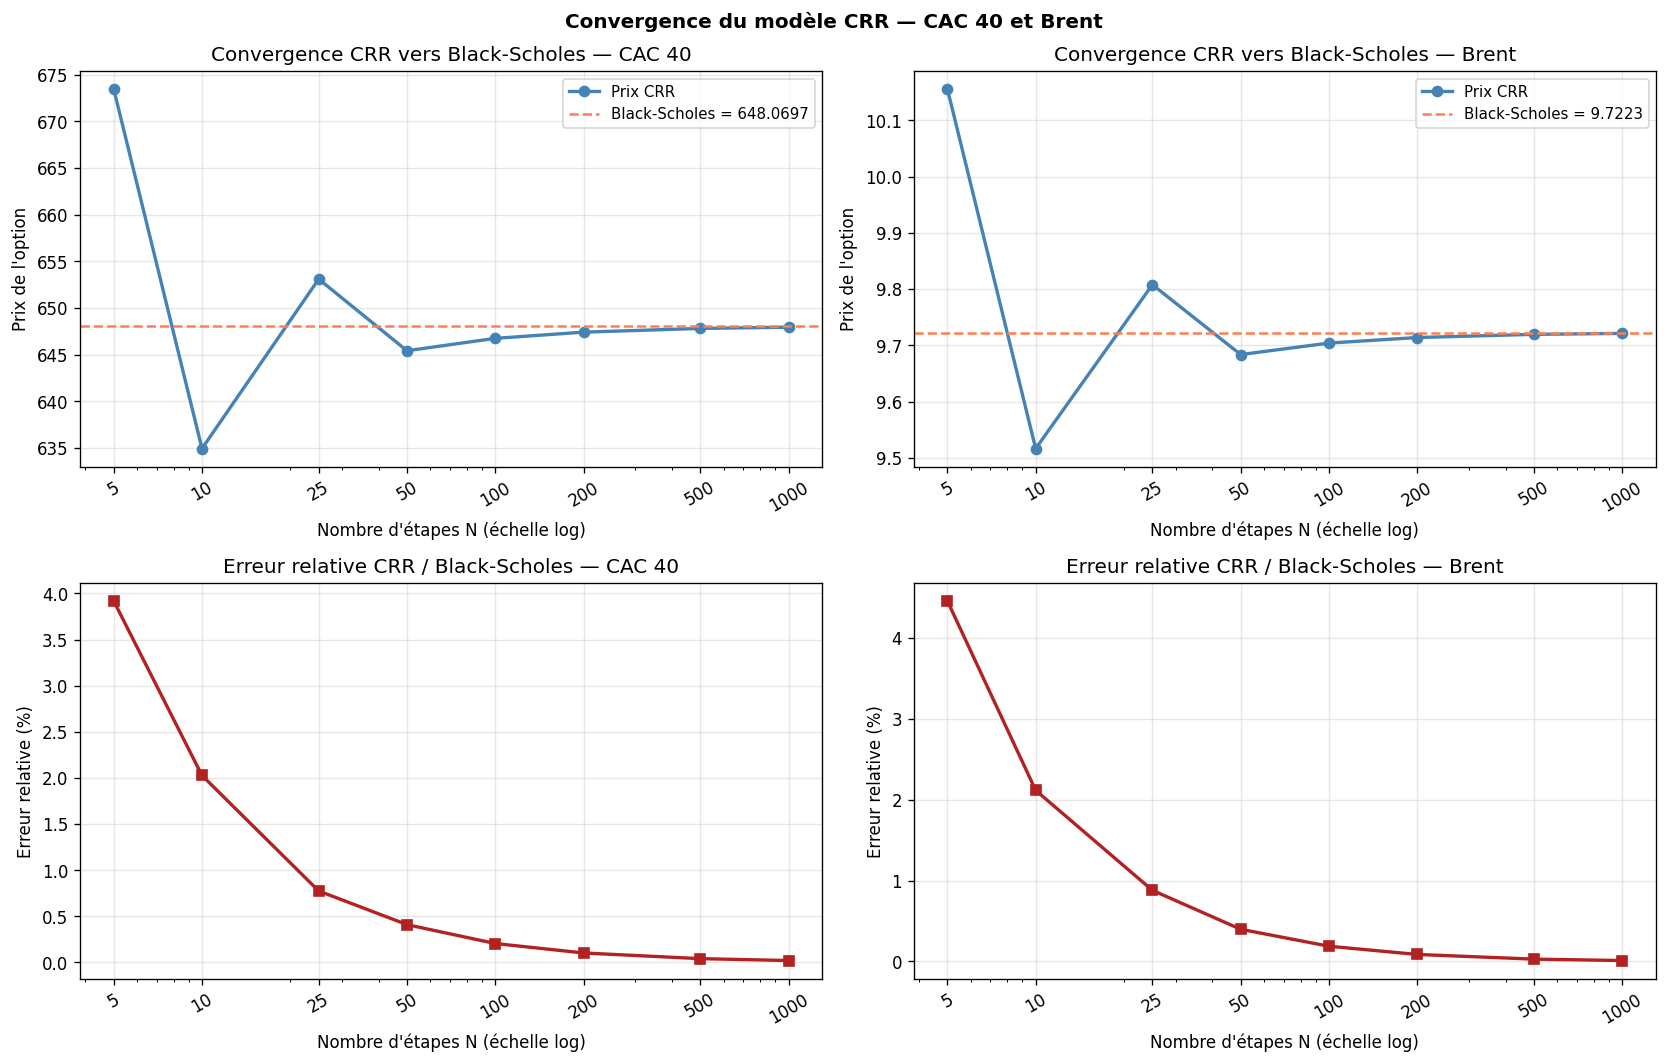

In [17]:
# --- Graphiques de convergence ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, name in enumerate(ASSETS):
    df_c     = pd.DataFrame(conv_data[name])
    price_bs = calibrations[name]["price_bs"]

    # Convergence du prix
    ax = axes[0, col]
    ax.plot(df_c["N"], df_c["Prix CRR"], marker="o", color="steelblue",
            linewidth=2, label="Prix CRR")
    ax.axhline(price_bs, color="coral", linestyle="--", linewidth=1.5,
               label=f"Black-Scholes = {price_bs:.4f}")
    ax.set_xscale("log")
    ax.set_xlabel("Nombre d'étapes N (échelle log)")
    ax.set_ylabel("Prix de l'option")
    ax.set_title(f"Convergence CRR vers Black-Scholes — {name}")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks(N_values)
    plt.setp(ax.get_xticklabels(), rotation=30)

    # Erreur relative
    ax = axes[1, col]
    ax.plot(df_c["N"], df_c["Erreur relative %"], marker="s",
            color="firebrick", linewidth=2)
    ax.set_xscale("log")
    ax.set_xlabel("Nombre d'étapes N (échelle log)")
    ax.set_ylabel("Erreur relative (%)")
    ax.set_title(f"Erreur relative CRR / Black-Scholes — {name}")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_xticks(N_values)
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.suptitle("Convergence du modèle CRR — CAC 40 et Brent", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("convergence_crr.png", bbox_inches="tight")
plt.show()

## 7. Comparaison entre prix réel du sous-jacent et trajectoire simulée

Cette section compare l'évolution réelle observée du sous-jacent avec une trajectoire simulée par le modèle CRR, construite en appliquant à chaque pas les facteurs u et d selon la probabilité risque-neutre p*.

Il s'agit ici d'une comparaison sur le *sous-jacent*, et non sur le prix de l'option. L'objectif est d'illustrer la cohérence entre la dynamique discrète du modèle et les prix historiques observés.

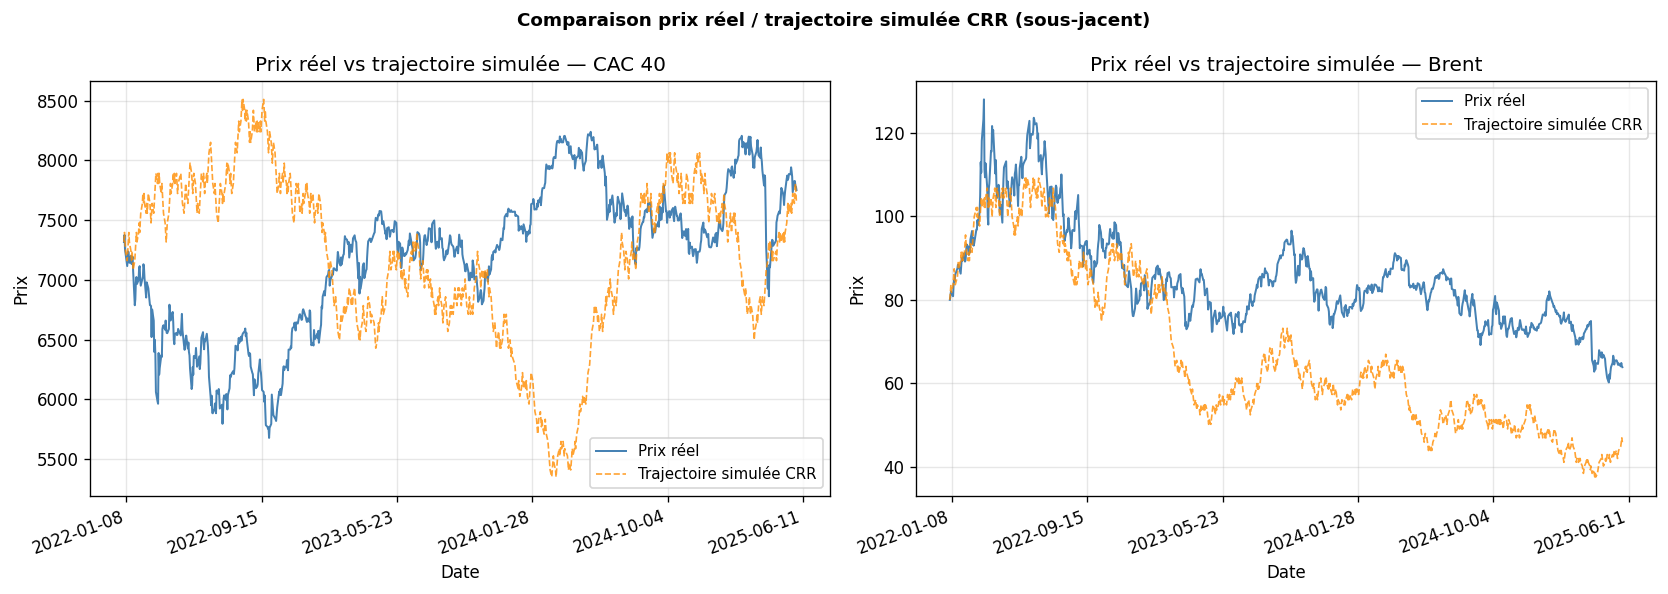

In [18]:
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    c    = calibrations[name]
    S0   = df["Close"].iloc[0]    # point de départ : premier prix de la période
    T_sim = (df.index[-1] - df.index[0]).days / 365
    N_sim = len(df)
    dt_sim = T_sim / N_sim

    # Recalcul de u et d avec le pas de temps journalier
    from calibration import compute_ud
    u_sim, d_sim = compute_ud(c["sigma"], dt_sim)

    # Simulation d'une trajectoire sous la probabilité risque-neutre
    traj = [S0]
    for _ in range(N_sim - 1):
        move = u_sim if np.random.rand() < c["p_star"] else d_sim
        traj.append(traj[-1] * move)

    ax.plot(df.index, df["Close"], color="steelblue", linewidth=1.2, label="Prix réel")
    ax.plot(df.index, traj, color="darkorange", linewidth=1.0,
            linestyle="--", alpha=0.8, label="Trajectoire simulée CRR")
    ax.set_title(f"Prix réel vs trajectoire simulée — {name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Prix")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Comparaison prix réel / trajectoire simulée CRR (sous-jacent)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("trajectoire_simulee.png", bbox_inches="tight")
plt.show()

La trajectoire simulée ne cherche pas à reproduire le chemin réel observé : elle en est une réalisation possible parmi une infinité. L'important est que la dispersion et l'ordre de grandeur des mouvements soient cohérents avec les données historiques, ce que garantit la calibration de sigma.

## 8. Backtest — évolution du prix de l'option dans le temps

Le backtest recalibre la volatilité à chaque date sur une fenêtre glissante de 252 jours (un an de trading), puis calcule le prix théorique de l'option par CRR et par Black-Scholes. La comparaison entre les deux séries montre si le modèle CRR reste cohérent avec la référence analytique au fil du temps.

**Remarque :** les prix obtenus sont des prix théoriques d'option, pas des prix observés sur un marché d'options. La comparaison est donc entre deux modèles de valorisation, et non entre un modèle et un prix de marché.

In [19]:
BACKTEST_WINDOW = 252  # fenêtre de calibration en jours

backtest_results = {}

for name, df in datasets.items():
    c = calibrations[name]
    option_bt = Option(strike=c["K"], maturity=T, option_type=OPTION_TYPE)

    bt = run_backtest(
        data=df,
        option=option_bt,
        pricing_function=crr_price,
        calibration_function=calibrate_crr_parameters,
        n_steps=N,
        risk_free_rate=R,
        window=BACKTEST_WINDOW
    )

    # Ajout du prix Black-Scholes recalibré à chaque date
    bs_prices = []
    for _, row in bt.iterrows():
        if pd.notna(row["sigma"]):
            bs = black_scholes_price(row["S"], c["K"], T, row["r"], row["sigma"], OPTION_TYPE)
        else:
            bs = np.nan
        bs_prices.append(bs)
    bt["prix_bs"] = bs_prices

    backtest_results[name] = bt
    print(f"{name} : {len(bt)} dates testées | prix CRR moyen = {bt['prix_prédit'].mean():.2f} | sigma moyen = {bt['sigma'].mean():.4f}")

CAC 40 : 619 dates testées | prix CRR moyen = 452.77 | sigma moyen = 0.1482
Brent : 604 dates testées | prix CRR moyen = 20.30 | sigma moyen = 0.3200


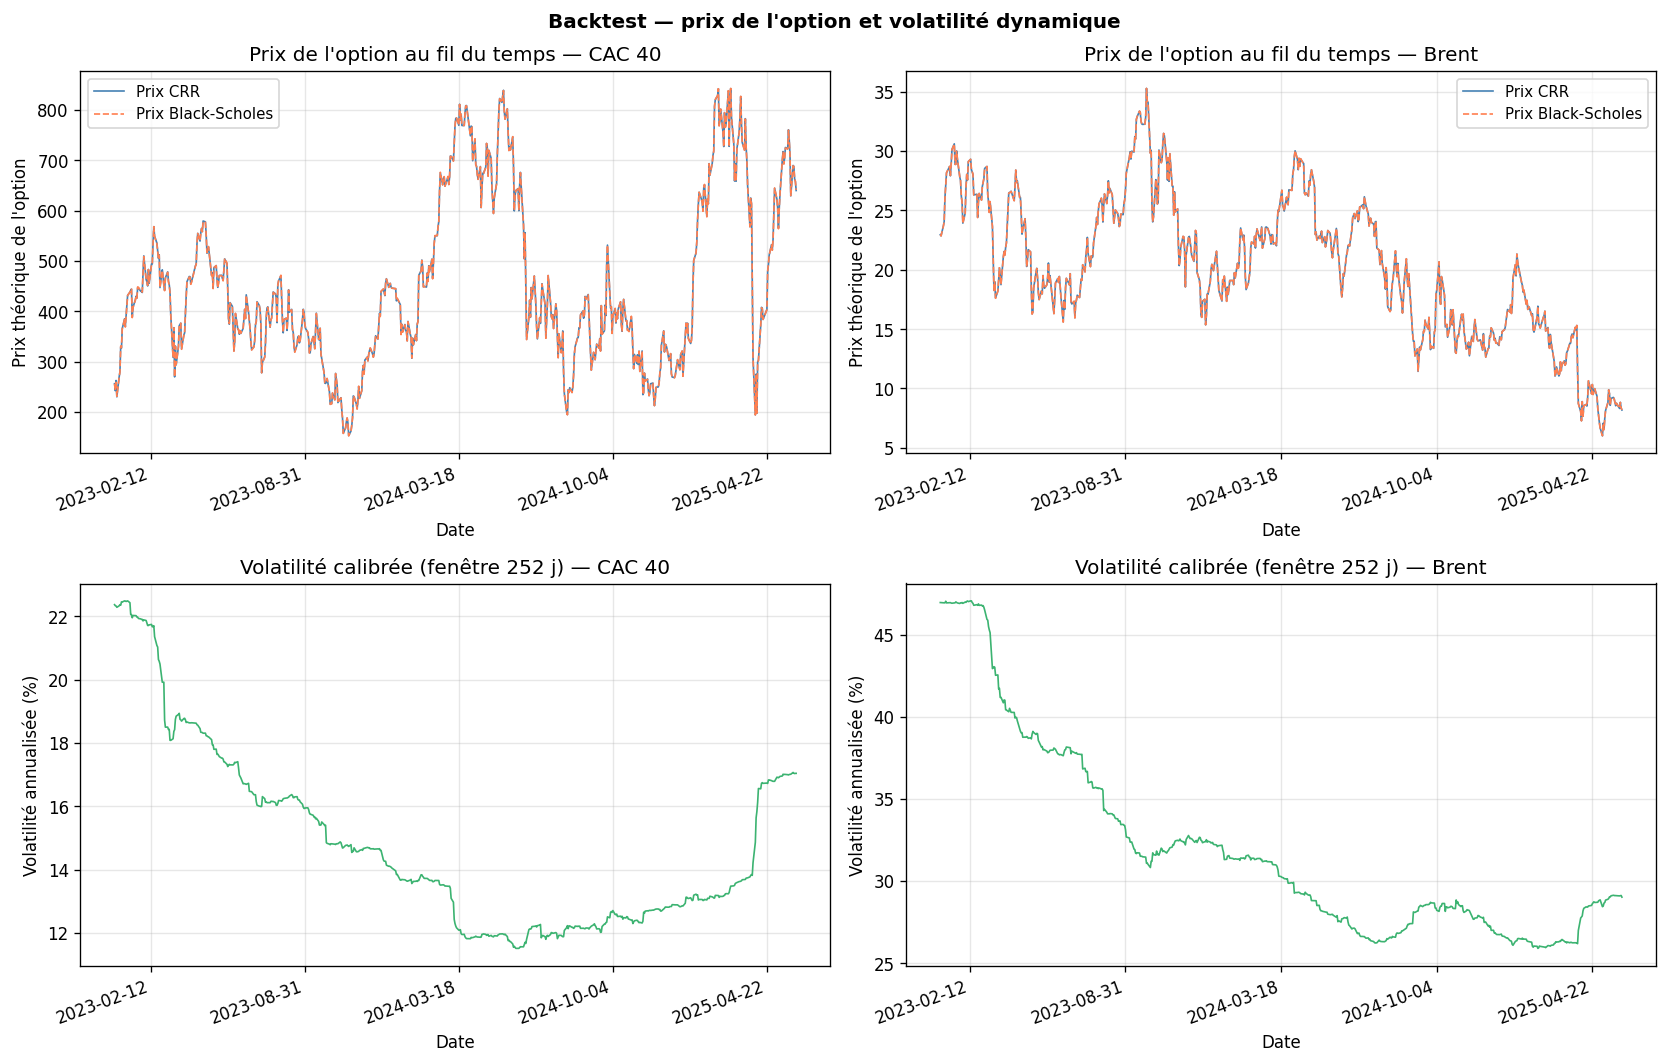

In [20]:
# --- Graphiques du backtest ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, name in enumerate(ASSETS):
    bt = backtest_results[name]

    # Prix de l'option au fil du temps
    ax = axes[0, col]
    ax.plot(bt["date"], bt["prix_prédit"], color="steelblue", linewidth=1.0,
            label="Prix CRR")
    ax.plot(bt["date"], bt["prix_bs"], color="coral", linewidth=1.0,
            linestyle="--", label="Prix Black-Scholes")
    ax.set_title(f"Prix de l'option au fil du temps — {name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Prix théorique de l'option")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

    # Volatilité calibrée
    ax = axes[1, col]
    ax.plot(bt["date"], bt["sigma"] * 100, color="mediumseagreen", linewidth=1.0)
    ax.set_title(f"Volatilité calibrée (fenêtre 252 j) — {name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatilité annualisée (%)")
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Backtest — prix de l'option et volatilité dynamique", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("backtest_prix_sigma.png", bbox_inches="tight")
plt.show()

In [21]:
# --- Résumé du backtest ---
for name, bt in backtest_results.items():
    summary = summarize_backtest_results(bt)
    print(f"\n--- {name} ---")
    for k, v in summary.items():
        print(f"  {k:<28} : {v}")


--- CAC 40 ---
  n_observations               : 619
  prix_moyen_predit            : 452.771050128508
  prix_min_predit              : 153.15465964380013
  prix_max_predit              : 841.993281217922
  sigma_moyen                  : 0.1482379230309262
  p_star_moyen                 : 0.5067469569257408
  n_nan                        : 0

--- Brent ---
  n_observations               : 604
  prix_moyen_predit            : 20.3036805298331
  prix_min_predit              : 6.007940504957654
  prix_max_predit              : 35.28348792301392
  sigma_moyen                  : 0.3199563967245879
  p_star_moyen                 : 0.49682525162334734
  n_nan                        : 0


## 9. Comparaison CAC 40 / Brent

Cette section synthétise les principales différences entre l'indice boursier CAC 40 et la matière première Brent en termes de volatilité, de prix d'option et de comportement du modèle CRR.

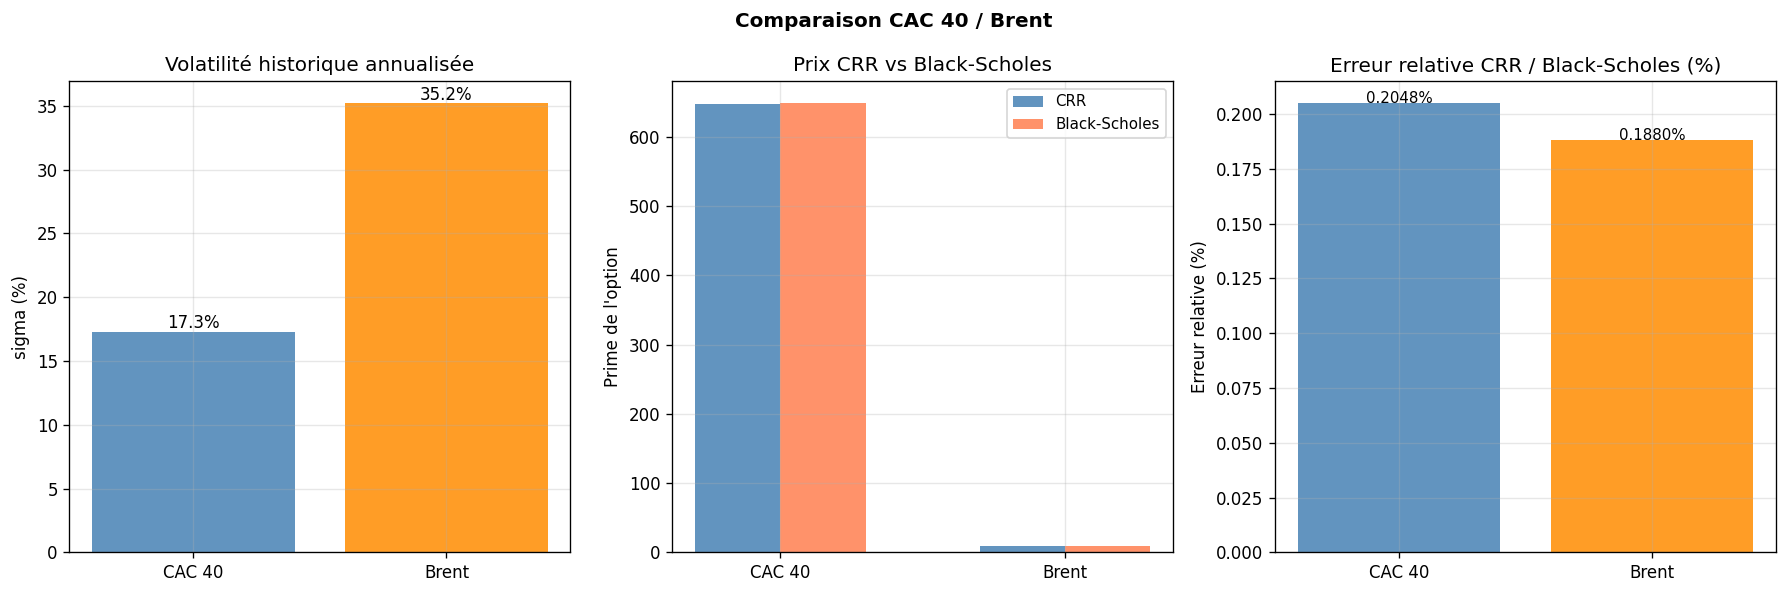

In [22]:
# --- Graphique comparatif : volatilité et prix d'option ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

actifs   = list(ASSETS.keys())
sigmas   = [calibrations[n]["sigma"] * 100 for n in actifs]
prices_crr = [calibrations[n]["price_crr"] for n in actifs]
prices_bs  = [calibrations[n]["price_bs"] for n in actifs]

x = np.arange(2)

# Volatilité
ax = axes[0]
ax.bar(actifs, sigmas, color=["steelblue", "darkorange"], alpha=0.85)
ax.set_title("Volatilité historique annualisée")
ax.set_ylabel("sigma (%)")
for i, v in enumerate(sigmas):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)

# Prix CRR vs BS
ax = axes[1]
w = 0.3
ax.bar(x - w/2, prices_crr, w, label="CRR",          color="steelblue", alpha=0.85)
ax.bar(x + w/2, prices_bs,  w, label="Black-Scholes", color="coral",     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(actifs)
ax.set_title("Prix CRR vs Black-Scholes")
ax.set_ylabel("Prime de l'option")
ax.legend(fontsize=9)

# Erreur relative
err_rel = [df_pricing.loc[df_pricing["Actif"] == n, "Erreur relative %"].values[0] for n in actifs]
ax = axes[2]
ax.bar(actifs, err_rel, color=["steelblue", "darkorange"], alpha=0.85)
ax.set_title("Erreur relative CRR / Black-Scholes (%)")
ax.set_ylabel("Erreur relative (%)")
for i, v in enumerate(err_rel):
    ax.text(i, v + 0.0001, f"{v:.4f}%", ha="center", fontsize=9)

plt.suptitle("Comparaison CAC 40 / Brent", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("comparaison_cac_brent.png", bbox_inches="tight")
plt.show()

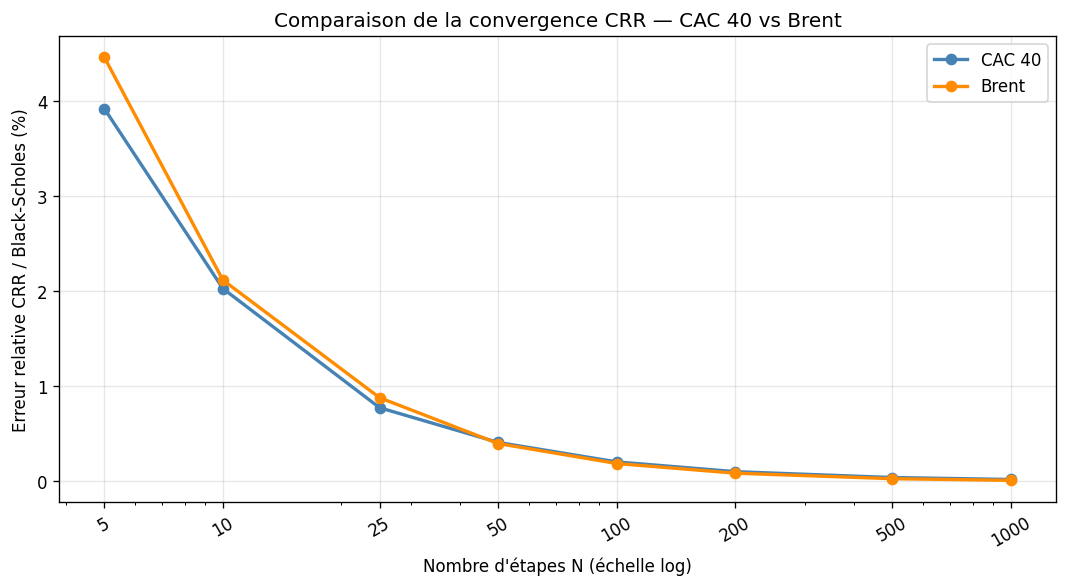

In [23]:
# --- Comparaison de la convergence CRR entre les deux actifs ---
fig, ax = plt.subplots(figsize=(9, 5))

colors = {"CAC 40": "steelblue", "Brent": "darkorange"}
for name in ASSETS:
    df_c     = pd.DataFrame(conv_data[name])
    ax.plot(df_c["N"], df_c["Erreur relative %"],
            marker="o", linewidth=2, label=name, color=colors[name])

ax.set_xscale("log")
ax.set_xlabel("Nombre d'étapes N (échelle log)")
ax.set_ylabel("Erreur relative CRR / Black-Scholes (%)")
ax.set_title("Comparaison de la convergence CRR — CAC 40 vs Brent")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(N_values)
plt.setp(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig("convergence_comparaison.png", bbox_inches="tight")
plt.show()

## 10. Interprétation académique

### Convergence du modèle CRR vers Black-Scholes

Le modèle CRR repose sur une discrétisation du temps en N intervalles de longueur dt = T/N. À chaque pas, le prix du sous-jacent peut monter d'un facteur u = exp(sigma * sqrt(dt)) ou baisser d'un facteur d = 1/u. Lorsque N augmente, dt tend vers 0, et la distribution des prix terminaux de l'arbre binomial converge en loi vers une lognormale, qui est l'hypothèse centrale de Black-Scholes. Le prix CRR converge donc vers le prix analytique, et l'erreur relative diminue en O(1/N).

### Rôle de la volatilité dans le prix de l'option

La volatilité sigma est le paramètre qui détermine l'amplitude des mouvements u et d. Une volatilité plus élevée élargit l'éventail des prix possibles à maturité, augmentant la probabilité que l'option se retrouve dans la monnaie, et donc son prix. C'est pourquoi, toutes choses égales par ailleurs, le prix d'une option sur le Brent tend à être plus élevé qu'une option ATM sur le CAC 40 si la volatilité du Brent est supérieure.

### CAC 40 vs Brent

Le CAC 40 est un indice diversifié sur 40 grandes capitalisations françaises, ce qui lisse naturellement les chocs idiosyncratiques des entreprises individuelles. Le Brent est un contrat à terme sur le pétrole brut, dont le prix dépend de facteurs géopolitiques, de décisions de production (OPEP), et de cycles macroéconomiques globaux. Ces facteurs génèrent des régimes de volatilité plus instables et des queues de distribution plus épaisses, ce qui rend le modèle de Black-Scholes moins adapté pour le Brent que pour un indice boursier.

### Limites de l'étude

- Les données `yfinance` fournissent les prix du sous-jacent, pas les prix d'options cotées. La comparaison principale reste donc entre deux modèles théoriques.
- La volatilité historique, estimée sur la période 2022-2025, ne reflète pas nécessairement la volatilité implicite future que le marché anticipe.
- Le modèle de Black-Scholes repose sur des hypothèses simplificatrices : marché continu, sans coûts de transaction, log-normalité stricte des rendements, et volatilité constante.
- Le modèle CRR dépend du choix de N, de T, de K et de la période historique retenue pour calibrer sigma.
- Le Brent présente des comportements de marché (sauts de prix, effets de contango, roulement de contrats) que ni CRR ni Black-Scholes ne capturent complètement.

## 11. Métriques globales

In [24]:
predicted  = df_pricing["Prix CRR"].values
reference  = df_pricing["Prix BS"].values

mae      = compute_mae(predicted, reference)
rmse     = compute_rmse(predicted, reference)
mean_err = np.mean(predicted - reference)
max_err  = np.max(np.abs(predicted - reference))
mean_rel = df_pricing["Erreur relative %"].mean()

print("Métriques globales — CRR vs Black-Scholes (N = 100)")
print("-" * 48)
print(f"  MAE  (Mean Absolute Error)  : {mae:.6f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.6f}")
print(f"  Erreur moyenne              : {mean_err:.6f}")
print(f"  Erreur maximale             : {max_err:.6f}")
print(f"  Erreur relative moyenne     : {mean_rel:.4f} %")

Métriques globales — CRR vs Black-Scholes (N = 100)
------------------------------------------------
  MAE  (Mean Absolute Error)  : 0.672850
  RMSE (Root Mean Sq. Error)  : 0.938703
  Erreur moyenne              : -0.672850
  Erreur maximale             : 1.327400
  Erreur relative moyenne     : 0.1964 %


---

*Notebook généré dans le cadre du projet 4A MAM — valorisation d'options par le modèle de Cox-Ross-Rubinstein.*